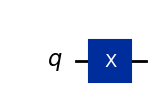

In [46]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.draw("mpl")

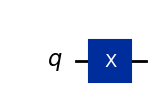

In [47]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.draw("mpl")

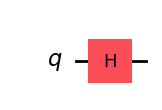

In [48]:
qc = QuantumCircuit(1)
qc.h(0)
qc.draw("mpl")

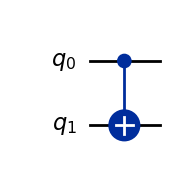

In [49]:
qc = QuantumCircuit(2)
qc.cx(0, 1) # |10> -> |11> / |11> -> |10>
qc.draw("mpl")

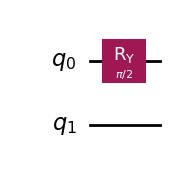

In [50]:
import numpy as np

pi = np.pi

qc = QuantumCircuit(2)
qc.ry(pi / 2, 0) # ROTATE THE STATES ABOUT THE Y-AXIS
qc.draw("mpl")

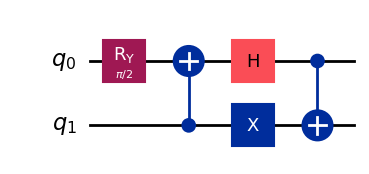

In [51]:
qc=QuantumCircuit(2)
qc.ry(pi/2,0)
qc.cx(1,0)
qc.x(1)
qc.h(0)
qc.cx(0,1)
qc.draw("mpl")

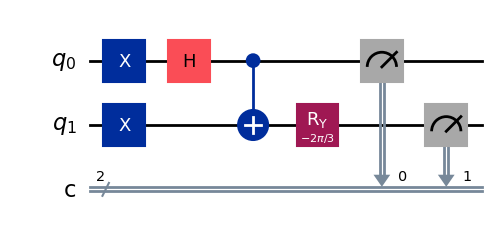

In [52]:
from qiskit.visualization import plot_histogram
from qiskit import ClassicalRegister, QuantumRegister

qr = QuantumRegister(2, "q")
cr = ClassicalRegister(2, "c")
qc1 = QuantumCircuit(qr, cr)

# We know from our analysis above that we need an X gate acting on each of the qubits (L and R)
qc1.x([0, 1])
# We need a Hadamard gate acting on Lucas's qubit, which we're calling the 0th qubit.
qc1.h(0)
# The controlled-NOT gate uses the 0th qubit (Lucas's) as the control and the 1st qubit (Rihanna's)
# as the target.
qc1.cx(0, 1)
# The rotation gate acts on the 1st qubit (Rihanna's) and has an argument of -2 pi/3
qc1.ry(-2 * pi / 3, 1)
# Finally, we want to measure all the qubits in the circuit to obtain measurement probabilities, and
# store the results in the classical bits.
qc1.measure([0, 1], [0, 1])
# Now we can draw the first of the three circuits that will check Bell's inequality for us.
qc1.draw(output="mpl")

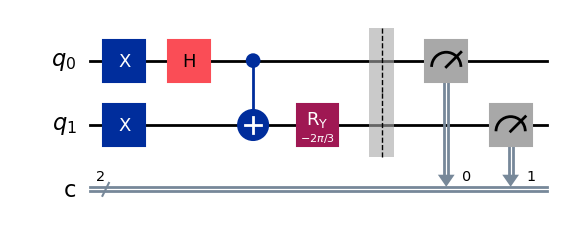

In [53]:
qcs = [QuantumCircuit(2, 2), QuantumCircuit(2, 2), QuantumCircuit(2, 2)]
for i in range(0, len(qcs)):
    qcs[i].x([0, 1])
    qcs[i].h(0)
    qcs[i].cx(0, 1)


qcs[0].ry(-2 * pi / 3, 1)
qcs[1].ry(-4 * pi / 3, 1)
qcs[2].ry(-2 * pi / 3, 1)
qcs[2].ry(-4 * pi / 3, 1) # QCS[2] ROTATING 0 DEGREES

for i in range(0, len(qcs)):
    qcs[i].barrier()
    qcs[i].measure([0, 1], [0, 1])

counts_list = [None] * len(qcs)

qcs[0].draw(output="mpl")

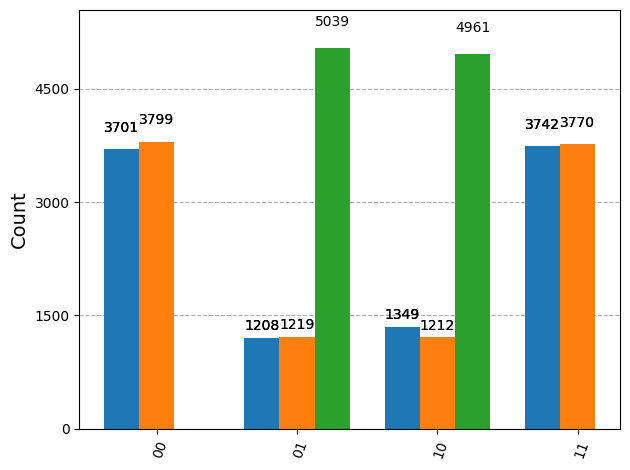

In [54]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

# Start a job that will return shots for all 100 parameter value sets.
for i in range(0, len(qcs)):
    pub = qcs[i]
    job = sampler.run([pub], shots=10000)
    # Extract the result for the 0th pub (this example only has one pub).
    result = job.result()
    data_pub = result[0].data
    counts = data_pub.c.get_counts()
    counts_list[i] = counts
#    plot_histogram(counts)

plot_histogram(counts_list)

{'00': 7500, '01': 7466, '10': 7522, '11': 7512}


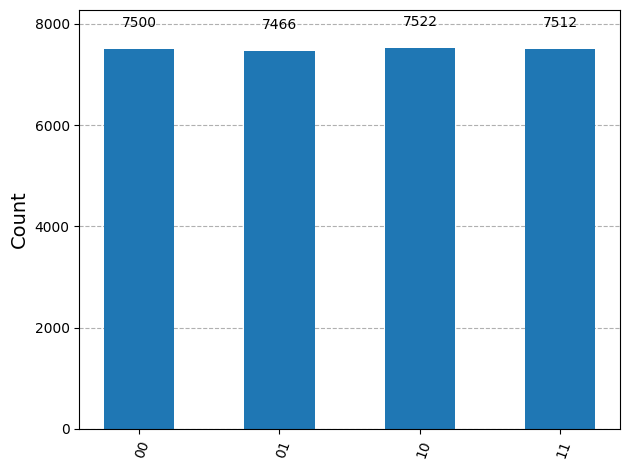

In [55]:
outcomes = ("00", "01", "10", "11")

# Here we convert "None"s into 0's so that we can sum.

for i in range(0, len(qcs)):
    for j in range(0, len(outcomes)):
        if counts_list[i].get(outcomes[j]) is None:
            counts_list[i].update({outcomes[j]: 0})

# Here we create a dictionary that holds all the outcomes and sums over their appearances
# in each of the circuits.

total_counts = {}
for i in range(0, len(outcomes)):
    total_counts[outcomes[i]] = sum(
        counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
    )

print(total_counts)
plot_histogram(total_counts) # 00 + 11 = 15,019 == 50%

In [56]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Syntax for first saving your token. Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform',
# instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True, min_num_qubits=qcs[0].num_qubits, simulator=False
)

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'

In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qcs_isa = qcs

for i in range(0, len(qcs)):
    qcs_isa[i] = pm.run(qcs[i])
    qcs_isa[i].draw(output="mpl", idle_wires=False, style="iqp")

    qcs_isa[2].draw(output="mpl", idle_wires=False, style="iqp")

NameError: name 'backend' is not defined

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime import Session
# sampler.options.default_shots = 1000

# Start a job that will return shots for all 100 parameter value sets.
# The best practice is to use a session as shown below. This is available to Premium Plan, Flex
# Plan, and On-Prem (IBM Quantum Platform API) Plan users.
# result_list = [None] * len(qcs)
# real_counts_list = [None] * len(qcs)
# with Session(backend=backend) as session:
#    sampler = Sampler(mode=session)

#    for i in range(0, len(qcs)):
#        # Define the primitive unified bloc (pub)
#        pub = qcs[i]
#        job = sampler.run([pub], shots=10000)
#        # Extract the result for the 0th pub (this example only has one pub).
#        result_list[i] = job.result()
#        data_pub = result_list[i][0].data
#        counts = data_pub.c.get_counts()
#        real_counts_list[i] = counts
#    #   plot_histogram(counts)

# Open users can still carry out this experiment, but without reserving a session of use, meaning
# repeated queuing is possible.
from qiskit_ibm_runtime import Batch

batch = Batch(backend=backend)
sampler = Sampler(mode=batch)

result_list = [None] * len(qcs)
real_counts_list = [None] * len(qcs)

for i in range(0, len(qcs)):
    # Define the primitive unified bloc (pub)
    pub = qcs[i]
    job = sampler.run([pub], shots=10000)
    # Extract the result for the 0th pub (this example only has one pub).
    result_list[i] = job.result()
    data_pub = result_list[i][0].data
    counts = data_pub.c.get_counts()
    real_counts_list[i] = counts

# Close the batch because no context manager was used.
batch.close()

In [ ]:
outcomes = ("00", "01", "10", "11")

# Here we convert "None"s into 0's so that we can sum.

for i in range(0, len(qcs)):
    for j in range(0, len(outcomes)):
        if real_counts_list[i].get(outcomes[j]) is None:
            real_counts_list[i].update({outcomes[j]: 0})

# Here we create a dictionary that holds all the outcomes and sums over their appearances
# in each of the circuits.

real_total_counts = {}
for i in range(0, len(outcomes)):
    real_total_counts[outcomes[i]] = sum(
        real_counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
    )

print(real_total_counts)
plot_histogram(real_total_counts)